# HUMAN

In [3]:
import sys, os, yaml, torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from scipy.spatial.distance import pdist

sys.path.append('/om2/user/jmhicks/projects/TextureStreaming/code/')
sys.path.append('/om2/user/bjmedina/auditory-memory/memory/utls/')
sys.path.append('/om2/user/bjmedina/auditory-memory/memory/src/model/')
sys.path.append('/om2/user/bjmedina/auditory-memory/memory/')

from chexture_choolbox.auditorytexture.texture_model import TextureModel
from chexture_choolbox.auditorytexture.helpers import FlattenStats
from texture_prior.params import model_params, statistics_set, texture_dataset
from texture_prior.utils import path

from utls.plotting import ensure_dir
from utls.loading import (
    load_results_with_exclusion_2,
    move_sequences_to_used,
    load_results_with_exclusion_no_dropping,
)
from utls.runners_v2 import run_experiment_scores, make_noise_schedule
from utls.runners_utils import *
from utls.analysis_helpers import auroc_to_dprime
from utls.io_utils import (
    make_model_save_dir,
    save_all_figures,
    save_single_figure,
    save_runs_summary,
)
from encoders import *

from utls.toy_experiments import (
    make_toy_experiment_list,
    make_compact_multi_isi_sequences,
    infer_trial_isis,
)
from utls.sigma_fitting import (
    log_mid,
    fit_sigma_1d,
    plot_sigma_fit,
)

## 1. Load config & data

In [4]:
def load_config(cfg_path):
    cfg_path = Path(cfg_path)
    if not cfg_path.exists():
        raise FileNotFoundError(cfg_path)
    with open(cfg_path) as f:
        return yaml.safe_load(f), cfg_path


CONFIG_PATH = (
    "/om2/user/bjmedina/auditory-memory/memory/"
    "model_yamls/three-regime/resnet50/nontime_avg/run_000005.yaml"
)

model_cfg, model_cfg_path = load_config(CONFIG_PATH)
print(model_cfg)

{'results_root': '/om2/user/bjmedina/auditory-memory/memory', 'tag': 'slurm', 'experiment': {'is_multi': True, 'n_seqs': 36, 'n_samples': 50, 'which_task': 0}, 'metric': 'cosine', 'noise_model': {'name': 'three-regime', 'sigma0_min': 3.0, 'sigma0_max': 0.5, 'sigma1_min': 0.1, 'sigma1_max': 0.6, 'sigma2_min': 0.0005, 'sigma2_max': 0.1, 't_step': 5}, 'run_id': 'run_000005', 'representation': {'type': 'resnet50', 'layer': 'layer4', 'time_avg': False}}


In [5]:
# ---- experiment ----
exp_cfg = model_cfg["experiment"]
which_task = exp_cfg["which_task"]
is_multi = exp_cfg["is_multi"]
which_isi = exp_cfg.get("which_isi", None)

isis = [0, 1, 2, 4, 8, 16, 32, 64] if is_multi else [0, which_isi]

# ---- metric ----
metric = model_cfg["metric"]

# ---- noise model ----
noise_cfg = model_cfg["noise_model"]
noise_mode = noise_cfg["name"]
t_step = noise_cfg["t_step"]

# ---- representation ----
repr_cfg = model_cfg["representation"]
time_avg = repr_cfg["time_avg"]
encoder_type = repr_cfg["type"]
layer = repr_cfg.get("layer", None)
pc_dims = repr_cfg.get("pc_dims", None)

# ---- load human data ----
exp_list, all_files, name_to_idx, human_runs, task_name, hr_task_name = (
    load_experiment_data(which_task, which_isi, is_multi, old=False)
)

human_curve = compute_human_curve(human_runs, is_multi, which_isi)
print("ISIs:", isis)
print("Human d' curve:", human_curve)
print(f"Total real sequences: {len(exp_list)}")

/om2/user/bjmedina/auditory-memory/memory/utls/runners_utils.py:210: RuntimeWarning: Mean of empty slice
  dprimes.append(np.nanmean(aucs))


ISIs: [0, 1, 2, 4, 8, 16, 32, 64]
Human d' curve: [3.37654516 2.90775169 2.34409659 2.11985719 1.94010024 1.87363722
 1.72771601 1.5675584 ]
Total real sequences: 104


## 2. Estimate how variable subsets of human data are

 --- full curve + bootstrap std ---
--- subsample curves across seeds: mean ± std for each num_exps ---


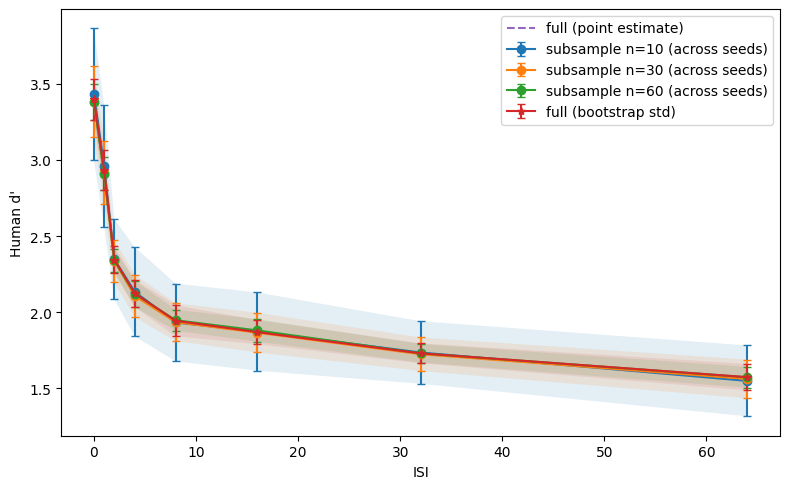

In [14]:
import warnings; warnings.filterwarnings("ignore")

# assumes: human_runs, is_multi, which_isi, isis, compute_human_curve imported/defined
num_exps_list = [10, 40, 80]
n_seeds = 200
seed_offset = 10_000

print(" --- full curve + bootstrap std ---")
# --- full curve + bootstrap std ---
human_full = np.asarray(compute_human_curve(human_runs, is_multi, which_isi), float)
rng = np.random.default_rng(123)
boot = np.vstack([
    np.asarray(
        compute_human_curve([human_runs[i] for i in rng.choice(len(human_runs), len(human_runs), replace=True)],
                            is_multi, which_isi),
        float
    )
    for _ in range(50)
])
full_mean = boot.mean(0)
full_std  = boot.std(0, ddof=1)

plt.figure(figsize=(8,5))

print("--- subsample curves across seeds: mean ± std for each num_exps ---")

# --- subsample curves across seeds: mean ± std for each num_exps ---
for j, num_exps in enumerate(num_exps_list):
    curves = []
    for base_seed in range(n_seeds):
        rngs = np.random.default_rng(base_seed + seed_offset)
        idx = rngs.choice(len(human_runs), size=num_exps, replace=False)
        subset = [human_runs[i] for i in idx]
        curves.append(np.asarray(compute_human_curve(subset, is_multi, which_isi), float))
    curves = np.vstack(curves)
    m, s = curves.mean(0), curves.std(0, ddof=1)

    plt.errorbar(isis, m, yerr=s, capsize=3, marker="o", label=f"subsample n={num_exps} (across seeds)")
    plt.fill_between(isis, m - s, m + s, alpha=0.12)

# --- full curve (bootstrap uncertainty) ---
plt.errorbar(isis, full_mean, yerr=full_std, capsize=3, marker="*", label="full (bootstrap std)")
plt.fill_between(isis, full_mean - full_std, full_mean + full_std, alpha=0.10)

# optional: point estimate from all runs
plt.plot(isis, human_full, "--", linewidth=1.5, label="full (point estimate)")

plt.xlabel("ISI")
plt.ylabel("Human d'")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
NN_ENCODERS = {"kell2018", "resnet50"}
encoder_task = (
    "word_speaker_audioset" if encoder_type in NN_ENCODERS else "audioset"
)

encoder_cfg = dict(
    encoder_type=encoder_type,
    model_name=encoder_type,
    task=encoder_task,
    statistics_dict=statistics_set.statistics,
    model_params=model_params,
    pc_dims=pc_dims,
    sr=20000,
    duration=2.0,
    rms_level=0.05,
    time_avg=time_avg,
    device="cuda",
)

if encoder_type in NN_ENCODERS:
    encoder_cfg["layer"] = layer
if encoder_type == "texture":
    encoder_cfg["pc_dims"] = pc_dims

encoder_name = make_encoder_name(encoder_cfg)
print("Encoder name:", encoder_name)

encoder = build_encoder(encoder_cfg)
X = encode_stimuli(encoder, all_files)
X_np = X.detach().cpu().numpy()
print("Encoded shape:", X_np.shape, "  any NaN?", torch.isnan(X).any().item())

Encoder name: resnet50-layer4
LOADING FROM /om2/user/bjmedina/models/cochdnn/model_directories/resnet50_word_speaker_audioset/
=> loading checkpoint '/om2/user/bjmedina/models/cochdnn/model_checkpoints/audio_rep_training_cochleagram_1/standard_training_word_and_audioset_and_speaker_decay_lr/542752d7-9849-49ff-b84a-6758a81585b4/5_checkpoint.pt'
=> loaded checkpoint '/om2/user/bjmedina/models/cochdnn/model_checkpoints/audio_rep_training_cochleagram_1/standard_training_word_and_audioset_and_speaker_decay_lr/542752d7-9849-49ff-b84a-6758a81585b4/5_checkpoint.pt' (epoch 6)
Encoded shape: (80, 186368)   any NaN? False


--- subsample curves across seeds: mean ± std for each num_exps ---


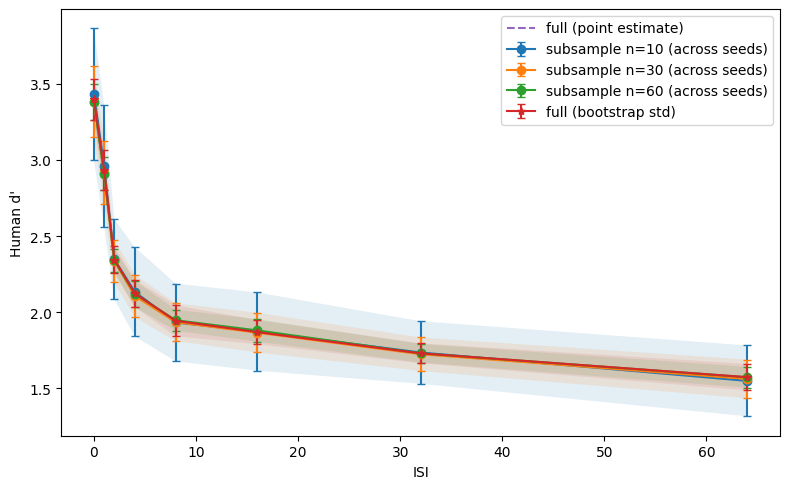

In [15]:
plt.figure(figsize=(8,5))

print("--- subsample curves across seeds: mean ± std for each num_exps ---")

# --- subsample curves across seeds: mean ± std for each num_exps ---
for j, num_exps in enumerate(num_exps_list):
    curves = []
    for base_seed in range(n_seeds):
        rngs = np.random.default_rng(base_seed + seed_offset)
        idx = rngs.choice(len(human_runs), size=num_exps, replace=False)
        subset = [human_runs[i] for i in idx]
        curves.append(np.asarray(compute_human_curve(subset, is_multi, which_isi), float))
    curves = np.vstack(curves)
    m, s = curves.mean(0), curves.std(0, ddof=1)

    plt.errorbar(isis, m, yerr=s, capsize=3, marker="o", label=f"subsample n={num_exps} (across seeds)")
    plt.fill_between(isis, m - s, m + s, alpha=0.12)

# --- full curve (bootstrap uncertainty) ---
plt.errorbar(isis, full_mean, yerr=full_std, capsize=3, marker="*", label="full (bootstrap std)")
plt.fill_between(isis, full_mean - full_std, full_mean + full_std, alpha=0.10)

# optional: point estimate from all runs
plt.plot(isis, human_full, "--", linewidth=1.5, label="full (point estimate)")

plt.xlabel("ISI")
plt.ylabel("Human d'")
plt.legend()
plt.tight_layout()
plt.show()